# Modélisation

Importation des modules

In [80]:
!pip install mord

In [81]:
import pandas as pd  
import numpy as np, pandas as pd, matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, chi2_contingency
from scipy.stats.contingency import association
from scipy.stats import mannwhitneyu, norm
import chardet
import unicodedata
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import mord
import mord as m
from patsy import dmatrices


## Importation des bases de données

In [82]:
base_finale= pd.read_csv("base_finale.csv", delimiter=",", low_memory=False)
base_f= pd.read_csv("base_f.csv", delimiter=";", low_memory=False)

In [83]:
base_finale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122252 entries, 0 to 122251
Data columns (total 56 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     122252 non-null  int64  
 1   Num_Acc        122252 non-null  int64  
 2   id_vehicule    122252 non-null  object 
 3   num_veh        122252 non-null  object 
 4   place          122252 non-null  int64  
 5   catu           122252 non-null  int64  
 6   grav           122252 non-null  int64  
 7   sexe           122252 non-null  int64  
 8   an_nais        122252 non-null  float64
 9   trajet         122252 non-null  float64
 10  secu1          122252 non-null  object 
 11  secu2          122252 non-null  object 
 12  actp           122252 non-null  object 
 13  senc           122252 non-null  object 
 14  catv           122252 non-null  object 
 15  obs            122252 non-null  object 
 16  obsm           122252 non-null  object 
 17  choc           122252 non-nul

In [84]:
base_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122252 entries, 0 to 122251
Data columns (total 55 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Num_Acc        122252 non-null  int64  
 1   id_vehicule    122252 non-null  object 
 2   num_veh        122252 non-null  object 
 3   place          122252 non-null  int64  
 4   catu           122252 non-null  object 
 5   grav           122252 non-null  int64  
 6   sexe           122252 non-null  object 
 7   an_nais        122252 non-null  float64
 8   trajet         122252 non-null  object 
 9   secu1          122252 non-null  object 
 10  secu2          122252 non-null  object 
 11  actp           122252 non-null  object 
 12  senc           122252 non-null  object 
 13  catv           122252 non-null  object 
 14  obs            122252 non-null  object 
 15  obsm           122252 non-null  object 
 16  choc           122252 non-null  object 
 17  manv           122252 non-nul

## Analyse sur la base base_f

Régression logistique : prédire la gravité
* Objectif : prédire si un usager est blessé (grav > 1) ou indemne.
* Quels facteurs (âge, sexe, type de véhicule, conditions météo, etc.) augmentent la probabilité d’être blessé ?

In [85]:
# 1. Création de la variable cible binaire : 0 = indemne, 1 = blessé/tué
base_f['cible_blesse'] = base_f['grav'].apply(lambda x: 0 if x == 1 else 1)

# 2. Liste des variables explicatives
variables = ['sexe', 'age', 'catv', 'catu', 'atm', 'lum', 'trajet', 'secu1', 'choc', 'manv', 'agg', 'vma', 'catr']

# 3. Sélection et suppression des lignes incomplètes
df_model = base_f[variables + ['cible_blesse']].dropna()

# 4. Encodage des variables catégorielles en variables binaires
X = pd.get_dummies(df_model.drop('cible_blesse', axis=1), drop_first=True)
X = X.astype(float)  #  Conversion explicite

y = df_model['cible_blesse'].astype(int)  #  Conversion explicite

# 5. Séparation en train et test (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# 6. Ajout de constante (intercept)
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# 7. Ajustement du modèle sur le jeu d'entraînement
model = sm.GLM(y_train, X_train_const, family=sm.families.Binomial())
result = model.fit()

# 8. Résultats sur le modèle entraîné
print("=== Résultats du GLM logistique (entraînement) ===")
print(result.summary())

# 9. Prédictions sur les données test
y_pred_proba = result.predict(X_test_const)
y_pred = (y_pred_proba >= 0.5).astype(int)

# 10. Évaluation du modèle
print("\n=== Évaluation sur le jeu de test ===")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))
print(f"Précision (Accuracy) : {accuracy_score(y_test, y_pred):.3f}")


=== Résultats du GLM logistique (entraînement) ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:           cible_blesse   No. Observations:                85576
Model:                            GLM   Df Residuals:                    85516
Model Family:                Binomial   Df Model:                           59
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -42987.
Date:                Sun, 22 Jun 2025   Deviance:                       85974.
Time:                        13:13:53   Pearson chi2:                 1.07e+05
No. Iterations:                    19   Pseudo R-squ. (CS):             0.2966
Covariance Type:            nonrobust                                         
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

Tableau d’odds ratios lisible

In [86]:
# === 1. Extraction des résultats ===
params = result.params
conf = result.conf_int()
conf.columns = ['2.5%', '97.5%']

# Calcul des odds ratios et ajout des colonnes
conf['OR'] = np.exp(params)
conf['p-value'] = result.pvalues
conf = conf[['OR', '2.5%', '97.5%', 'p-value']]  # Réorganisation des colonnes
conf.index.name = 'variable'
conf = conf.reset_index()  # Pour que 'variable' devienne une colonne du DataFrame

# === 2. Séparation en deux blocs : OR > 1 (effet positif), OR < 1 (effet protecteur) ===
positives = conf[conf['OR'] > 1].sort_values(by='OR', ascending=False)
negatives = conf[conf['OR'] < 1].sort_values(by='OR')  # du plus protecteur vers 1

# === 3. Fusion des deux blocs pour affichage ordonné
conf_sorted = pd.concat([positives, negatives])

# === 4. Affichage final de toutes les variables ===
print("\n=== Tableau des coefficients (toutes les variables) triés par effet ===")
print(conf_sorted[['variable', 'OR', '2.5%', '97.5%', 'p-value']].round(3).to_string(index=False))



=== Tableau des coefficients (toutes les variables) triés par effet ===
                                                   variable           OR       2.5%     97.5%  p-value
                                       secu1_Gants + Airbag 52386101.171 -24136.077 24171.625    0.999
                                                catu_Piéton       27.588      3.132     3.502    0.000
                              catv_Deux-roues non motorisés        4.855      0.819     2.341    0.000
                                             choc_Multichoc        4.339      1.309     1.627    0.000
                                                      const        3.411     -0.202     2.656    0.092
                                  catv_Deux-roues motorisés        2.340      0.091     1.609    0.028
                                              catu_Passager        1.873      0.583     0.672    0.000
                                     agg_Hors agglomération        1.839      0.555     0.663    0.000


In [87]:
print("\n=== Interprétation automatisée des facteurs significatifs (p < 0.10) ===")
# 1. Filtrage des variables significatives
signif = conf[(conf['p-value'] < 0.10) & (conf['p-value'] > 0)]
# 2. Variables à effet positif (OR > 1)
positives = signif[signif['OR'] > 1]
# 3. Variables à effet négatif (OR < 1)
negatives = signif[signif['OR'] < 1]
# 4. Affichage des effets positifs d'abord
print(f"==============Les variables à effet positif=================")
for var, row in positives.iterrows():
    print(f"++ La variable '{var}' augmente la probabilité d'être blessé (OR = {row['OR']:.2f}, p = {row['p-value']:.3f}).")
print(f"==============Les variables à effet négatif=================")
# 5. Puis des effets négatifs
for var, row in negatives.iterrows():
    print(f"-- La variable '{var}' diminue la probabilité d'être blessé (OR = {row['OR']:.2f}, p = {row['p-value']:.3f}).")


=== Interprétation automatisée des facteurs significatifs (p < 0.10) ===
==============Les variables à effet positif=================
++ La variable '0' augmente la probabilité d'être blessé (OR = 3.41, p = 0.092).
++ La variable '2' augmente la probabilité d'être blessé (OR = 1.01, p = 0.000).
++ La variable '5' augmente la probabilité d'être blessé (OR = 2.34, p = 0.028).
++ La variable '6' augmente la probabilité d'être blessé (OR = 4.86, p = 0.000).
++ La variable '13' augmente la probabilité d'être blessé (OR = 1.87, p = 0.000).
++ La variable '14' augmente la probabilité d'être blessé (OR = 27.59, p = 0.000).
++ La variable '23' augmente la probabilité d'être blessé (OR = 1.24, p = 0.000).
++ La variable '24' augmente la probabilité d'être blessé (OR = 1.31, p = 0.000).
++ La variable '25' augmente la probabilité d'être blessé (OR = 1.30, p = 0.008).
++ La variable '40' augmente la probabilité d'être blessé (OR = 1.16, p = 0.001).
++ La variable '41' augmente la probabilité d'êt

### Modèle multinomial

* Comment les variables influencent la probabilité d’appartenir à chaque niveau de gravité ?
* Par exemple, les deux-roues augmentent-ils spécifiquement le risque d’hospitalisation (et pas juste d’être blessé) ?

In [88]:
# 1. Variables explicatives et variable cible (gravité exacte)
variables = ['sexe', 'age', 'catv', 'catu', 'atm', 'lum', 'trajet', 'secu1', 'choc', 'manv']
df_model = base_f[variables + ['grav']].dropna()

# 2. Encodage des variables catégorielles
X = pd.get_dummies(df_model.drop('grav', axis=1), drop_first=True)
X = X.astype(float)  # Conversion explicite pour éviter les erreurs
y = df_model['grav'].astype(int)  # Gravité : 1=Indemne, 2=Tué, 3=Blessé hospitalisé, 4=Blessé léger

# 3. Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# 4. Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Modèle de régression logistique multinomiale
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
model.fit(X_train_scaled, y_train)

# 6. Prédictions et évaluation
y_pred = model.predict(X_test_scaled)

#  stocker l'accuracy multinomiale pour réutilisation dans le Code 4
accuracy_multi = accuracy_score(y_test, y_pred)

# Affichage
print("=== Évaluation du modèle multinomial : prédiction de la gravité exacte ===")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))
print(f"Précision (accuracy) globale : {accuracy_multi:.3f}")


c:\Users\sonex\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Évaluation du modèle multinomial : prédiction de la gravité exacte ===
[[13030     3    99  2221]
 [  354     9   208   380]
 [ 1611     6   678  3196]
 [ 5938     3   492  8448]]
              precision    recall  f1-score   support

           1      0.622     0.849     0.718     15353
           2      0.429     0.009     0.019       951
           3      0.459     0.123     0.195      5491
           4      0.593     0.568     0.580     14881

    accuracy                          0.604     36676
   macro avg      0.526     0.387     0.378     36676
weighted avg      0.581     0.604     0.566     36676

Précision (accuracy) globale : 0.604


Graphique de la matrice de confusion

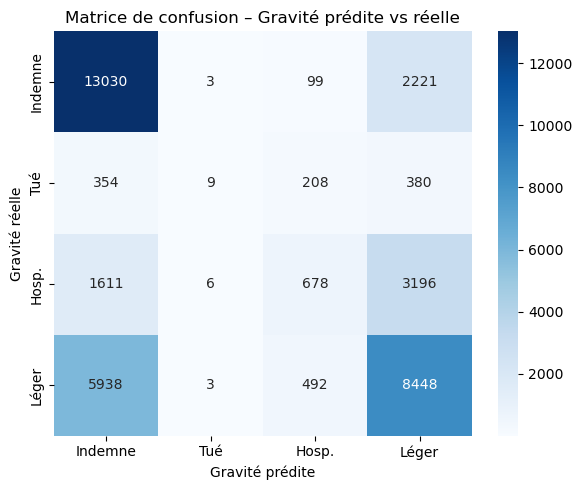

In [89]:
# Générer et afficher la matrice de confusion
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=["Indemne", "Tué", "Hosp.", "Léger"],
            yticklabels=["Indemne", "Tué", "Hosp.", "Léger"])
plt.title("Matrice de confusion – Gravité prédite vs réelle")
plt.xlabel("Gravité prédite")
plt.ylabel("Gravité réelle")
plt.tight_layout()
plt.show()


Analyse automatique des facteurs influents (par classe)

In [90]:
print("=== Analyse automatique des coefficients par classe ===")
classes = model.classes_
coefs = model.coef_

for i, classe in enumerate(classes):
    print(f"\n➡ Gravité prédite : {classe}")
    top_vars = pd.Series(coefs[i], index=X.columns).sort_values(ascending=False)
    
    print("+++++++ Facteurs qui augmentent la probabilité +++++++++:")
    print(top_vars.head(5).round(3))
    
    print("-------- Facteurs qui la diminuent ----------:")
    print(top_vars.tail(5).round(3))


=== Analyse automatique des coefficients par classe ===

➡ Gravité prédite : 1
+++++++ Facteurs qui augmentent la probabilité +++++++++:
secu1_Ceinture               0.344
catv_Véhicules légers pro    0.169
catv_Véhicules légers        0.157
manv_Stationnement/Arrêt     0.152
manv_Changement de voie      0.152
dtype: float64
-------- Facteurs qui la diminuent ----------:
catv_Deux-roues non motorisés   -0.214
choc_Avant                      -0.217
catv_Deux-roues motorisés       -0.256
secu1_Casque                    -0.262
catu_Piéton                     -0.469
dtype: float64

➡ Gravité prédite : 2
+++++++ Facteurs qui augmentent la probabilité +++++++++:
age                               0.378
choc_Avant                        0.291
secu1_Aucun                       0.272
choc_Aucun                        0.193
lum_Nuit sans éclairage public    0.176
dtype: float64
-------- Facteurs qui la diminuent ----------:
manv_Stationnement/Arrêt    -0.117
catv_Autre                  -0.118
lum

comparer au logit ordinal

In [91]:
# Régression logistique ordinale
ord_model = m.LogisticAT(alpha=1.0)
ord_model.fit(X_train_scaled, y_train)
y_pred_ord = ord_model.predict(X_test_scaled)

# Évaluation
accuracy_ord = accuracy_score(y_test, y_pred_ord)  # stocke l'accuracy pour la comparaison
print("=== Évaluation du modèle ordinal (LogisticAT) ===")
print(confusion_matrix(y_test, y_pred_ord))
print(classification_report(y_test, y_pred_ord, digits=3))
print(f"Précision (accuracy) modèle ordinal: {accuracy_ord:.3f}")
print(f"Précision (accuracy) modèle multinomial: {accuracy_multi:.3f}")

# ---  Conclusion automatique ---
print("\n=== Conclusion sur le choix du modèle ===")
if accuracy_multi > accuracy_ord:
    print(f"Le modèle **multinomial** présente de meilleures performances (accuracy = {accuracy_multi:.3f}) "
          f"que le modèle ordinal (accuracy = {accuracy_ord:.3f}). Le modèle **multinomial** est donc retenu.")
elif accuracy_ord > accuracy_multi:
    print(f"Le modèle **ordinal** présente de meilleures performances (accuracy = {accuracy_ord:.3f}) "
          f"que le modèle multinomial (accuracy = {accuracy_multi:.3f}). Le modèle **ordinal** est donc retenu.")
else:
    print(f"Les deux modèles présentent une performance équivalente (accuracy = {accuracy_ord:.3f}). "
          "Le choix dépendra alors d'autres critères comme l'interprétabilité.")


=== Évaluation du modèle ordinal (LogisticAT) ===
[[10541  1104  2694  1014]
 [  275    49   154   473]
 [ 1135   190   891  3275]
 [ 3775   855  3144  7107]]
              precision    recall  f1-score   support

           1      0.670     0.687     0.678     15353
           2      0.022     0.052     0.031       951
           3      0.129     0.162     0.144      5491
           4      0.599     0.478     0.531     14881

    accuracy                          0.507     36676
   macro avg      0.355     0.344     0.346     36676
weighted avg      0.544     0.507     0.522     36676

Précision (accuracy) modèle ordinal: 0.507
Précision (accuracy) modèle multinomial: 0.604

=== Conclusion sur le choix du modèle ===
Le modèle **multinomial** présente de meilleures performances (accuracy = 0.604) que le modèle ordinal (accuracy = 0.507). Le modèle **multinomial** est donc retenu.


## logit ordinal

In [92]:
# 1. Sélection des variables explicatives ( suppression du doublon 'choc')
variables = ['sexe', 'age', 'catv', 'catu', 'atm', 'lum', 'trajet', 'secu1', 'choc', 'manv', 'agg']

# 2. Création du DataFrame propre pour la modélisation
df_model = base_f[variables + ['ordre_gravite']].dropna()

# 3. Encodage des variables catégorielles
X = pd.get_dummies(df_model.drop('ordre_gravite', axis=1), drop_first=True).astype(float)

# 4. Définition de la variable cible (ordre_gravite)
y = df_model['ordre_gravite'].astype(int)

# 5. Séparation des données en train et test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# 6. Standardisation des variables explicatives
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Modèle de logit ordinal (Adjacent Threshold)
model = mord.LogisticAT(alpha=1.0)
model.fit(X_train_scaled, y_train)

# 8. Prédictions sur les données test
y_pred_ord = model.predict(X_test_scaled)


# 9. Évaluation du modèle
print("=== Évaluation du modèle de logit ordinal : prédiction de la gravité ordinale ===")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))
print(f"Précision (accuracy) globale : {accuracy_score(y_test, y_pred):.3f}")

# 10. Affichage des coefficients et des seuils
print("\n=== Résumé du modèle de logit ordinal (coefficients et seuils) ===")
coefficients = pd.Series(model.coef_, index=X.columns)
print("\n--- Coefficients des variables explicatives ---")
print(coefficients.sort_values(ascending=False))

print("\n--- Seuils de coupure (intercepts entre les catégories) ---")
print(model.theta_)



=== Évaluation du modèle de logit ordinal : prédiction de la gravité ordinale ===
[[13030     3    99  2221]
 [ 5938     3   492  8448]
 [ 1611     6   678  3196]
 [  354     9   208   380]]
              precision    recall  f1-score   support

           1      0.622     0.849     0.718     15353
           2      0.143     0.000     0.000     14881
           3      0.459     0.123     0.195      5491
           4      0.027     0.400     0.050       951

    accuracy                          0.384     36676
   macro avg      0.313     0.343     0.241     36676
weighted avg      0.388     0.384     0.331     36676

Précision (accuracy) globale : 0.384

=== Résumé du modèle de logit ordinal (coefficients et seuils) ===

--- Coefficients des variables explicatives ---
agg_Hors agglomération                       0.504376
catu_Piéton                                  0.219549
choc_Avant                                   0.216142
catv_Deux-roues motorisés                    0.194465
choc

matrice de confusion

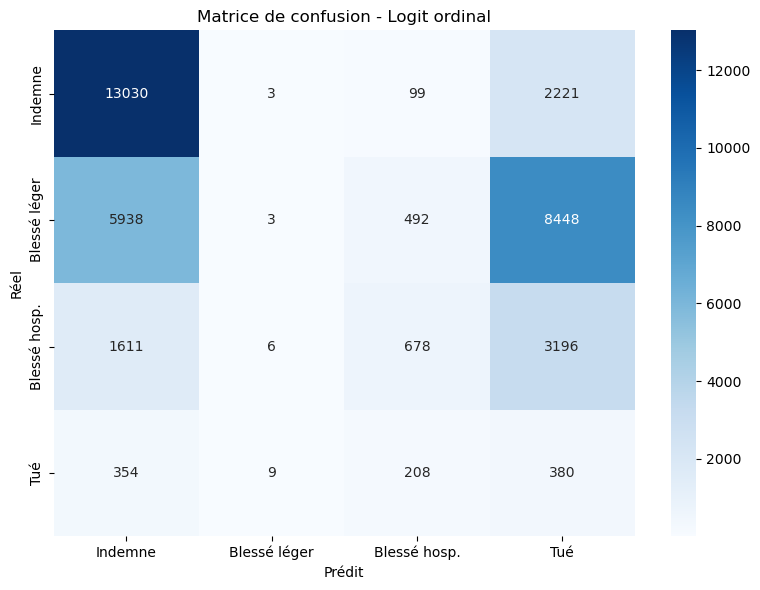

In [93]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Indemne", "Blessé léger", "Blessé hosp.", "Tué"],
            yticklabels=["Indemne", "Blessé léger", "Blessé hosp.", "Tué"])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Logit ordinal")
plt.tight_layout()
plt.show()


Analyse automatique des facteurs influents pour chaque classe

In [94]:
top_n = 5

# Création du DataFrame des coefficients
summary_df = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_
})

# Trier pour extraire les plus influents
print("\n=== Principaux facteurs associés à une gravité PLUS élevée ===")
print(summary_df[summary_df['Coefficient'] > 0]
      .sort_values(by='Coefficient', ascending=False)
      .head(top_n)
      .to_string(index=False))

print("\n=== Principaux facteurs associés à une gravité MOINS élevée ===")
print(summary_df[summary_df['Coefficient'] < 0]
      .sort_values(by='Coefficient', ascending=True)
      .head(top_n)
      .to_string(index=False))



=== Principaux facteurs associés à une gravité PLUS élevée ===
                 Variable  Coefficient
   agg_Hors agglomération     0.504376
              catu_Piéton     0.219549
               choc_Avant     0.216142
catv_Deux-roues motorisés     0.194465
           choc_Multichoc     0.169546

=== Principaux facteurs associés à une gravité MOINS élevée ===
                 Variable  Coefficient
           secu1_Ceinture    -0.927342
              secu1_Autre    -0.332374
catv_Véhicules légers pro    -0.184345
        catv_Poids lourds    -0.177289
  manv_Changement de voie    -0.148929


Comparaison avec une régression logistique multinomiale

In [95]:
# Modèle de régression logistique multinomiale
model_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
model_multi.fit(X_train_scaled, y_train)

# Prédictions et évaluation
y_pred_multi = model_multi.predict(X_test_scaled)  #  Nom clair et cohérent
accuracy_multi = accuracy_score(y_test, y_pred_multi)


c:\Users\sonex\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [96]:
# Comparaison des performances globales
accuracy_ord = accuracy_score(y_test, y_pred_ord)         # pour le modèle ordinal
accuracy_multi = accuracy_score(y_test, y_pred_multi)     # pour le modèle multinomial

# Choix du modèle le plus performant
if accuracy_multi > accuracy_ord:
    conclusion = ("Le modèle de régression logistique **multinomiale** présente de meilleures performances "
                  f"(accuracy = {accuracy_multi:.3f}) que le modèle ordinal (accuracy = {accuracy_ord:.3f}).\n"
                  "Le modèle **multinomial** est donc retenu.")
else:
    conclusion = ("Le modèle de régression logistique **ordinale** présente de meilleures performances "
                  f"(accuracy = {accuracy_ord:.3f}) que le modèle multinomial (accuracy = {accuracy_multi:.3f}).\n"
                  "Le modèle **ordinal** est donc retenu.")

print("\n=== Conclusion sur le choix du modèle ===")
print(conclusion)



=== Conclusion sur le choix du modèle ===
Le modèle de régression logistique **multinomiale** présente de meilleures performances (accuracy = 0.615) que le modèle ordinal (accuracy = 0.585).
Le modèle **multinomial** est donc retenu.


In [97]:
# On utilise gravité dans sa version d'origine (1 à 4)
df_model_multi = base_f[variables + ['grav']].dropna()

# Encodage des variables catégorielles sous forme de formules
formula = 'grav ~ ' + ' + '.join(variables)

# Modèle multinomial avec gravité comme variable nominale
model_mn = smf.mnlogit(formula, data=df_model_multi).fit(method='newton', maxiter=100, full_output=True, disp=False)

print(model_mn.summary())


c:\Users\sonex\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                          MNLogit Regression Results                          
Dep. Variable:                   grav   No. Observations:               122252
Model:                        MNLogit   Df Residuals:                   122096
Method:                           MLE   Df Model:                          153
Date:                Sun, 22 Jun 2025   Pseudo R-squ.:                  0.2007
Time:                        13:15:49   Log-Likelihood:            -1.0867e+05
converged:                      False   LL-Null:                   -1.3595e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      grav=2       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                                       -3.4378      0.988     -3.479      0.001      -5.374      -1.501
sexe[T.Homme]                

### Régression de Poisson
Modélise le nombre de victimes par accident (nb_victimes) en fonction de facteurs comme :
* type de lieu, conditions météo, nombre d’usagers, etc.
* Pour voir quels facteurs influencent le nombre de victimes dans un accident ?

In [98]:
# 1. Regrouper par accident pour obtenir le nombre de victimes par accident
df_poisson = base_f.groupby('Num_Acc').agg({
    'grav': lambda x: sum(x > 1),  # nombre de blessés (blessé léger, hospitalisé, tué)
    'lum': 'first',
    'atm': 'first',
    'nb_usagers': 'first',  # total des usagers dans l'accident
    'col': 'first',         # type de collision
    'agg': 'first',          # type de zone
    'choc':'first'
}).rename(columns={'grav': 'nb_victimes'}).dropna()

# 2. Modèle de Poisson (avec formules de patsy)
# 'C(...)' transforme les variables catégorielles en indicateurs
formula = "nb_victimes ~ C(lum) + C(atm) + nb_usagers + C(col) + C(agg)"
y, X = dmatrices(formula, data=df_poisson, return_type='dataframe')

# 3. Modèle de Poisson
poisson_model = sm.GLM(y, X, family=sm.families.Poisson())
poisson_results = poisson_model.fit()

print("=== Régression de Poisson – Nombre de victimes par accident ===")
print(poisson_results.summary())


=== Régression de Poisson – Nombre de victimes par accident ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:            nb_victimes   No. Observations:                56387
Model:                            GLM   Df Residuals:                    56366
Model Family:                 Poisson   Df Model:                           20
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -65361.
Date:                Sun, 22 Jun 2025   Deviance:                       11501.
Time:                        13:15:54   Pearson chi2:                 1.14e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1044
Covariance Type:            nonrobust                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

Coefficients et intervalles de confiance

In [99]:
# Coefficients et intervalles de confiance
params = poisson_results.params
conf_int = poisson_results.conf_int()
conf_int.columns = ['2.5%', '97.5%']

# Calcul des Odds Ratios (exp(coef))
or_poisson = np.exp(params)
conf_int['OR'] = or_poisson
conf_int['p-value'] = poisson_results.pvalues
conf_int = conf_int[['OR', '2.5%', '97.5%', 'p-value']]

# Affichage
print("=== Effet multiplicatif (exp(coef)) sur le nombre de victimes ===")
print(conf_int.sort_values(by='OR', ascending=False).round(3))


=== Effet multiplicatif (exp(coef)) sur le nombre de victimes ===
                                         OR   2.5%  97.5%  p-value
nb_usagers                            1.197  0.176  0.185    0.000
C(agg)[T.Hors agglomération]          1.142  0.116  0.150    0.000
C(lum)[T.Nuit sans éclairage public]  1.067  0.028  0.102    0.001
C(lum)[T.Nuit éclairage allumé]       1.056  0.020  0.089    0.002
C(lum)[T.Nuit éclairage non allumé]   1.039 -0.047  0.123    0.383
C(atm)[T.Brouillard/fumée]            0.999 -0.129  0.126    0.985
C(atm)[T.Vent fort/tempête]           0.995 -0.188  0.178    0.957
C(atm)[T.Temps couvert]               0.983 -0.121  0.088    0.754
C(lum)[T.Plein jour]                  0.976 -0.054  0.006    0.114
C(atm)[T.Normale]                     0.974 -0.124  0.072    0.604
C(atm)[T.Pluie légère]                0.960 -0.141  0.059    0.418
C(atm)[T.Pluie forte]                 0.959 -0.152  0.068    0.456
C(atm)[T.Éblouissement]               0.954 -0.160  0.065    0.

In [100]:
# === Test de surdispersion dans le modèle de Poisson ===
deviance = poisson_results.deviance
ddl = poisson_results.df_resid
phi = deviance / ddl

print("=== Test de surdispersion ===")
print(f"Déviance du modèle : {deviance:.2f}")
print(f"Degrés de liberté résiduels : {ddl}")
print(f"Rapport phi (déviance / ddl) : {phi:.2f}")

# Interprétation académique
if phi > 1.5:
    print("Surdispersion détectée : le modèle de Poisson est inadapté. "
          "Il est recommandé d'utiliser un modèle de type quasi-Poisson ou binomial négatif.")
else:
    print("Absence de surdispersion significative : le modèle de Poisson est considéré comme approprié.")


=== Test de surdispersion ===
Déviance du modèle : 11501.47
Degrés de liberté résiduels : 56366
Rapport phi (déviance / ddl) : 0.20
Absence de surdispersion significative : le modèle de Poisson est considéré comme approprié.


### modèle Quasi-Poisson
* Le modèle Quasi-Poisson relâche l’hypothèse de variance égale à la moyenne.
* Il ajuste les erreurs-types sans changer les coefficients estimés.

In [101]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from patsy import dmatrices

# 1. Regrouper par accident pour obtenir le nombre de victimes par accident 
df_poisson = base_f.groupby('Num_Acc').agg({
    'grav': lambda x: sum(x > 1),  # nombre de blessés (blessé léger, hospitalisé, tué)
    'lum': 'first',
    'atm': 'first',
    'nb_usagers': 'first',         # nombre d'usagers
    'col': 'first',                # type de collision
    'agg': 'first',                # type de zone
    'choc': 'first'
}).rename(columns={'grav': 'nb_victimes'}).dropna()

# 2. Construction des matrices via patsy
formula = "nb_victimes ~ C(lum) + C(atm) + nb_usagers + C(col) + C(agg)"
y, X = dmatrices(formula, data=df_poisson, return_type='dataframe')

# 3. Modèle quasi-Poisson (GLM avec famille Poisson et variance robuste)
quasi_poisson_model = sm.GLM(y, X, family=sm.families.Poisson())
quasi_poisson_results = quasi_poisson_model.fit(cov_type='HC0')  # robust standard errors

# 4. Affichage
print("=== Régression Quasi-Poisson – Nombre de victimes par accident (avec variance robuste) ===")
print(quasi_poisson_results.summary())


=== Régression Quasi-Poisson – Nombre de victimes par accident (avec variance robuste) ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:            nb_victimes   No. Observations:                56387
Model:                            GLM   Df Residuals:                    56366
Model Family:                 Poisson   Df Model:                           20
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -65361.
Date:                Sun, 22 Jun 2025   Deviance:                       11501.
Time:                        13:16:00   Pearson chi2:                 1.14e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1044
Covariance Type:                  HC0                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------